# Connected cluster corrections

Cluster cumulant expansions reorganize overlapping loop corrections by Möbius inversion on a partially ordered set of clusters. The cumulant of a disconnected cluster vanishes, and truncation can be organized by cluster size or estimated contribution.

In [1]:
CHAPTER_DIR = "ch09"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Exact subgraph partition functions

We use a five-spin graph with two overlapping cycles. For every edge cluster we compute the exact zero-field partition function normalized by its independent-spin value.

largest cumulants


,cluster edges,cumulant,cluster
5,1,1.595376e-01,"[(4, 2)]"
4,1,1.392205e-01,"[(3, 4)]"
3,1,1.201145e-01,"[(2, 3)]"
29,3,1.125004e-01,"[(2, 3), (3, 4), (4, 2)]"
2,1,1.022667e-01,"[(2, 0)]"
1,1,8.572272e-02,"[(1, 2)]"
0,1,7.052649e-02,"[(0, 1)]"
16,3,6.007771e-02,"[(0, 1), (1, 2), (2, 0)]"
49,6,2.220446e-15,"[(0, 1), (1, 2), (2, 0), (2, 3), (3, 4), (4, 2)]"
47,5,-1.332268e-15,"[(0, 1), (2, 0), (2, 3), (3, 4), (4, 2)]"


Saved: figs/ch09_03_cumulant_spectrum_and_truncation.pdf


Saved: figs/ch09_03_cumulant_spectrum_and_truncation.png


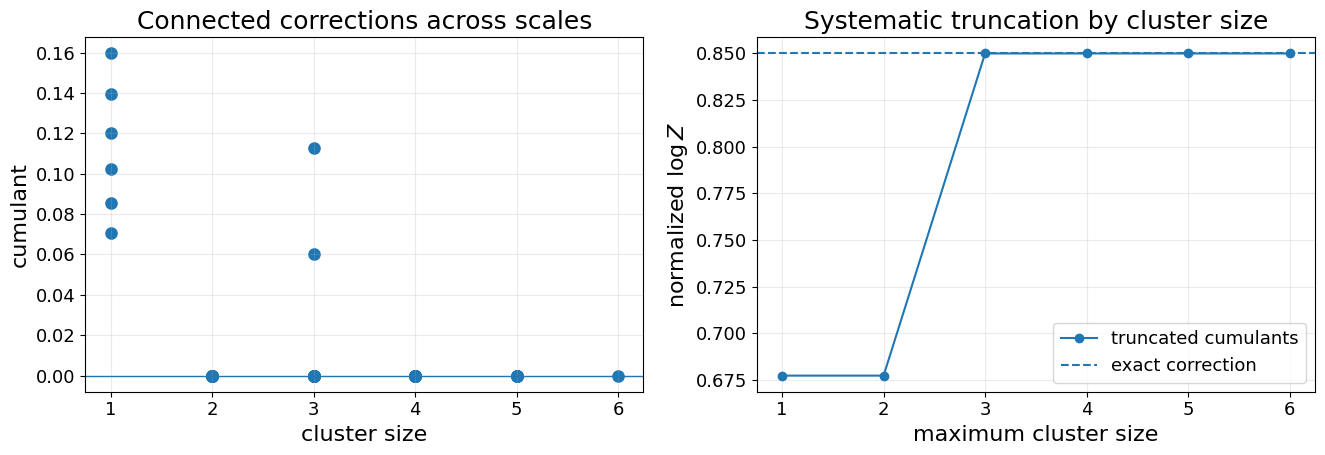

In [2]:
from itertools import product,combinations
nodes=range(5); all_edges=[(0,1),(1,2),(2,0),(2,3),(3,4),(4,2)]; J={e:.38+.04*k for k,e in enumerate(all_edges)}
def logZ(E):
    active=sorted(set(sum(([i,j] for i,j in E),[])))
    if not active: return 0.
    states=list(product([-1,1],repeat=len(active))); idx={v:k for k,v in enumerate(active)}
    z=sum(np.exp(sum(J[e]*x[idx[e[0]]]*x[idx[e[1]]] for e in E)) for x in states)
    return np.log(z)-len(active)*np.log(2)
clusters=[]
for r in range(1,len(all_edges)+1):
    for E in combinations(all_edges,r):
        H=nx.Graph(); H.add_edges_from(E)
        if nx.is_connected(H): clusters.append(frozenset(E))
clusters.sort(key=len)
cum={}
for C in clusters: cum[C]=logZ(C)-sum(v for D,v in cum.items() if D<C)
rows=pd.DataFrame([(len(C),cum[C],str(sorted(C))) for C in clusters],columns=['cluster edges','cumulant','cluster'])
print('largest cumulants'); display(rows.reindex(rows.cumulant.abs().sort_values(ascending=False).index).head(12))
fig,axes=plt.subplots(1,2,figsize=(13.5,4.8)); axes[0].scatter(rows['cluster edges'],rows['cumulant'],s=65); axes[0].axhline(0,linewidth=1); axes[0].set_xlabel('cluster size'); axes[0].set_ylabel('cumulant'); axes[0].set_title('Connected corrections across scales'); axes[0].grid(alpha=.25)
exact=logZ(all_edges); approx=[]
for k in range(1,len(all_edges)+1): approx.append(sum(v for C,v in cum.items() if len(C)<=k))
axes[1].plot(range(1,len(all_edges)+1),approx,marker='o',label='truncated cumulants'); axes[1].axhline(exact,linestyle='--',label='exact correction'); axes[1].set_xlabel('maximum cluster size'); axes[1].set_ylabel('normalized $\\log Z$'); axes[1].set_title('Systematic truncation by cluster size'); axes[1].legend(); axes[1].grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch09_03_cumulant_spectrum_and_truncation'); plt.show()

## Disconnected-cluster cancellation

In [3]:
C1=frozenset([(0,1)]); C2=frozenset([(3,4)]); disconnected=C1|C2
c_dis=logZ(disconnected)-logZ(C1)-logZ(C2)
print('disconnected cumulant =',c_dis); assert abs(c_dis)<1e-12

disconnected cumulant = 0.0


## Exercises

1. Order clusters by absolute estimated cumulant rather than size.
2. Compare edge-cluster and region-cluster posets.
3. Identify which symmetries force groups of cumulants to be equal.
4. Propose an adaptive stopping rule based on the observed cumulant tail.